# <b> Binary Search Tree </b>

In [2]:
class TreeNode:
    def __init__(self, x):
        self.val = x
        self.left = None
        self.right = None

In [3]:
class BST(TreeNode):
    def __init__(self, val, parent=None):
        super().__init__(val)
        self.parent = parent

    def insert(self, val):
        if val < self.val:   # insert into left
            if self.left is None:
                new_node = BST(val, self)
                self.left = new_node
            else:
                self.left.insert(val)

        else: # greater
            if self.right is None:
                new_node = BST(val, self)
                self.right = new_node
            else:
                self.right.insert(val)

In [4]:
from graphviz import Digraph

def visualize_tree(tree):
    if tree is None: return 'Nothing in the tree!'
    def add_nodes_edges(tree, dot=None):
        # Create Digraph object
        if dot is None:
            dot = Digraph()
            dot.attr('node', shape='circle')
            dot.node(name=str(tree), label=str(tree.val))
            
        for child in [tree.left, tree.right]:  # do for all children
            if child is not None:
                if child == tree.left: dot.attr('node', shape='circle', style='filled', fillcolor='lightblue')
                if child == tree.right: dot.attr('node', shape='doublecircle', style='filled', fillcolor='lightpink')
                dot.node(name=str(child), label=str(child.val))
                dot.edge(str(tree), str(child))
                dot = add_nodes_edges(child, dot=dot)  # recursive call
                
        return dot

    # Add nodes recursively and create a list of edges
    dot = add_nodes_edges(tree)

    # Visualize the graph
    display(dot)

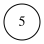

In [5]:
b1 = BST(5)
visualize_tree(b1)

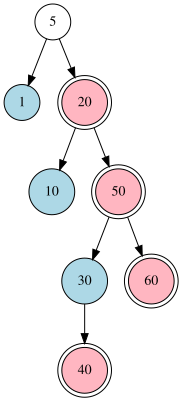

In [6]:
b1.insert(1)
b1.insert(20)
b1.insert(10)
b1.insert(50)
b1.insert(30)
b1.insert(60)
b1.insert(40)
visualize_tree(b1)

## Deletion From the BST 

First, we'll need some helper functions. Let's discuss those first.

In [7]:
def find_root(self):
    """ Find the absolute root of the BST to which self belongs. Keep going up untill you find None """

    temp = self
    while temp.parent is not None:
        temp = temp.parent

    return temp

BST.find_root = find_root

In [8]:
b1.find_root().val

5

In [9]:
def find_min(self):
    """ Find the minimum value starting from self. In BST, this is simple, keep going left until no more left is left. """

    min_node = self

    if min_node.left is not None:
        min_node = self.left.find_min()

    return min_node

BST.find_min = find_min

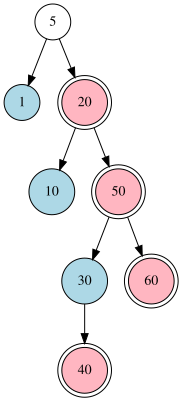

Min is :  1


In [10]:
visualize_tree(b1)
print("Min is : ", b1.find_min().val)

In [11]:
b1.right.find_min().val

10

In [12]:
def set_for_parent(self, new_ref):
    if self.parent is None:
        return 

    if self.parent.right == self:
        self.parent.right = new_ref

    if self.parent.left == self:
        self.parent.left = new_ref

BST.set_for_parent = set_for_parent

In [13]:
def replace_with_node(self, node):
    """ Replace self with node (which is a child). Make sure to fix the parent of the node """

    self.set_for_parent(node) # connect new_node to parent on proper location
    node.parent = self.parent

    return node.find_root() #find root again

BST.replace_with_node = replace_with_node

In [14]:
def delete(self, val):
    # first ... if we are alone, on the root and no children's plus the value also matches just return None 

    if self.parent is None and self.right is None and self.left is None and self.val == val:
        return None

    # we are the node to be deleted 
    if self.val == val:
        # check if we are leaf
        if self.left is None and self.right is None:
            self.set_for_parent(None)
            return self.find_root()

        # check if we have just a left node
        if self.right is None:
            return self.replace_with_node(self.left)

        # check if we have just a right node 
        if self.left is None:
            return self.replace_with_node(self.right)


        # now we have both children. Find the successor and replace "self" with it
        # (our succ is definately in our right child and it cannot have two children because left child will always be smaller)

        successor = self.right.find_min()

        # copy the successor val here
        self.val = successor.val

        return self.right.delete(successor.val)

        # ^ delete the successor node. which is in our right child BST.
        # ^ Its guaranted that it's the simpler case since successor CANNOT have a left child.
    

    if val < self.val:
        if self.left is not None:
            return self.left.delete(val)
        else:
            return self.find_root()     # nothing to delete
    else:
        if self.right is not None:
            return self.right.delete(val)
        else:
            return self.find_root() 

BST.delete = delete 

## <b> Issue with the BST - Balance </b>

In [15]:
l = [1, 2, 4, 9, 13, 21, 51, 71, 82]

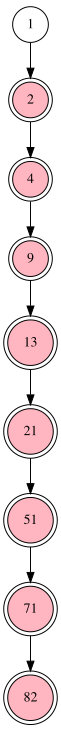

In [18]:
b = BST(l[0])
for i in l[1:]:
    b.insert(i)
visualize_tree(b)

It seems like a linked list 

In [ ]:
The issue is resolving using advanced BSTs such as <b> RB Tree </b> and <b> AVL Trees </b>. Balance is achieved using the concpet of rotation based on different